# Example Problem: Toy Tomography Problem

> **Colab note:** This notebook is designed to run on **Google Colab**. The first code cell installs dependencies. [![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/drive/1yP-nEXnYA35TERPV6tQHMp-krMmxAPbd?usp=sharing)

This Jupyter notebook will solve the toy tomography problem in Section 5.5.2.

```{figure} ../figures/05_toy_problem.png
---
name: Toy Tomography Problem Set Up
width: 400px
---
Here is the (a) the model and ray geomogety for a 2D toy problem, (b) the test input velocity model to create synthetic data, and (c) the least squares solution.
```

In this problem, we assume the model has no velocity perturbations (s=0) in all cells except the cell in the middle of the velocity model.

In [1]:
# Install dependencies (for Google Colab or missing packages)
import sys
import subprocess

# Detect environment
try:
    import google.colab
    IN_COLAB = True
    print("Running in Google Colab")
except ImportError:
    IN_COLAB = False
    print("Running in local environment")

# Required packages (module_name : pip_name)
required_packages = {
    'numpy': 'numpy',
    'matplotlib': 'matplotlib',
    'ipywidgets': 'ipywidgets',
    'IPython': 'ipython',
    'scipy': 'scipy'
}

missing_packages = []

# Check for missing packages
for module_name, pip_name in required_packages.items():
    try:
        __import__(module_name)
        print(f"✓ {module_name} is already installed")
    except ImportError:
        missing_packages.append(pip_name)
        print(f"✗ {module_name} not found")

# Install if needed
if missing_packages:
    print(f"\nInstalling: {', '.join(missing_packages)}")

    if IN_COLAB:
        subprocess.check_call(["pip", "install", "-q"] + missing_packages)
    else:
        subprocess.check_call([sys.executable, "-m", "pip", "install"] + missing_packages)

    print("✓ Installation complete!")

else:
    print("\n✓ All required packages are installed!")

# Imports (run after install)
import numpy as np
import matplotlib.pyplot as plt
import ipywidgets as widgets
from IPython.display import display, clear_output
from scipy.sparse import lil_matrix, vstack, eye, csr_matrix
from scipy.sparse.linalg import lsqr
from ipywidgets import interact, interactive_output, VBox, HBox

# Matplotlib inline for notebooks
try:
    get_ipython().run_line_magic('matplotlib', 'inline')
except:
    pass

print("\n✓ All imports successful!")

Running in local environment
✓ numpy is already installed
✓ matplotlib is already installed
✓ ipywidgets is already installed
✓ IPython is already installed
✓ scipy is already installed

✓ All required packages are installed!

✓ All imports successful!


## First, let's define all our various matrices.

In this case, the data are the traveltime residuals for the rays: $d_1$ to $d_6$.

In this case, the model is a $3$ by $3$ matrix where each square has a slowness perturbation, $s_k$. We must also define the true velocity model, $m_{true}$, in order to calculate our forward model.

The $G$ matrix relates the data $d$ and the model $m$.

In [43]:
"""
Define matrices and the inverse problem
"""

# TODO: Define Data
# The data are the residual traveltimes through the true model. The matrix size is n x 1, where n is the number of data points.
d = np.array([0,1,0,0,1,0]) 

# TODO: Define true model
# Define the true slowness perturbation model. The matrix size m x 1, where m is the number of model parameters.
m_true = np.array([0,0,0,0,1,0,0,0,0])

# TODO: Define the G matrix
# This model relates the model to the data. The values are the distance each ray passes through each model square. 
# The matrix is size n x m.
G = np.array([[1,1,1,0,0,0,0,0,0],
              [0,0,0,1,1,1,0,0,0],
              [0,0,0,0,0,0,1,1,1], 
              [1,0,0,1,0,0,1,0,0],
              [0,1,0,0,1,0,0,1,0],
              [0,0,1,0,0,1,0,0,1]])

# TODO: Define the least-squares matrix solution
# In this case, we are solving for m that fits the data.
### Note: Matrix transpose in Python numpy is x.T
### Note: Matrix multiplication in Python numpy is @
### Note: In this case, G is ill-conditioned. Use the pseudoinverse function to do the matrix inverse: np.linalg.pinv()
m = np.linalg.pinv(G.T @ G) @ G.T @ d

Least squares solution: 
 [[-0.11111111  0.22222222 -0.11111111]
 [ 0.22222222  0.55555556  0.22222222]
 [-0.11111111  0.22222222 -0.11111111]] 



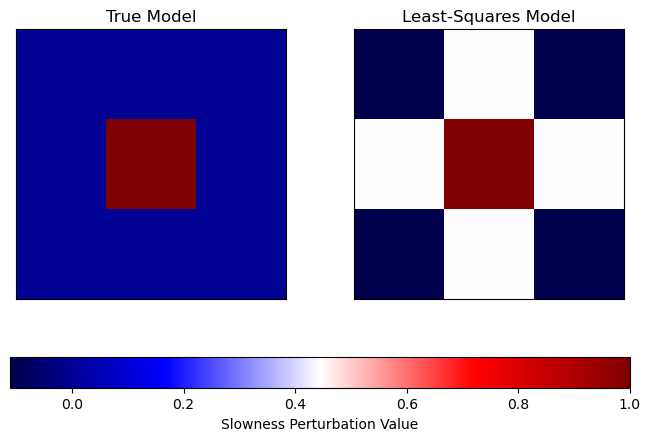

In [61]:
"""
Plot the true versus the calculated models
---
DO NOT EDIT
"""
m = m.reshape(3,3)
print('Least squares solution: \n',m,'\n')


# Plot the resulting slowness model solution
def plot_model(ax, m, nx, ny, title,vmin,vmax):
    vmax = np.max(np.abs(m)) + 1e-10

    im = ax.imshow(
        m.reshape(ny, nx),
        cmap='seismic',
        vmin=vmin,
        vmax=vmax,
    )

    ax.set_title(title)
    ax.set_xticks([])
    ax.set_yticks([])
    return im

fig,ax = plt.subplots(1,2,figsize=(8,5))
im1 = plot_model(ax[0], m_true, 3, 3, 'True Model',vmin=np.min(m),vmax=np.max(m_true))
im2 = plot_model(ax[1], m, 3, 3, 'Least-Squares Model',vmin=np.min(m),vmax=np.max(m_true))
plt.colorbar(im1,ax=[ax[0],ax[1]],orientation='horizontal',cmap='seismic',location='bottom',label='Slowness Perturbation Value')
plt.show()

In [ ]:
"""
Add Regularization
"""

